In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import re
import matplotlib.pyplot as plt

In [108]:
pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)  
pd.set_option('display.max_colwidth', None)  

In [109]:
csv_file = "/Users/vidhyakshayakannan/Downloads/cleaned_data/L1_test_deepseek-ai-DeepSeek-V3_cleaned.csv"
df = pd.read_csv(csv_file)
df["question_lower"] = df["question"].str.lower()
templates = [
    {
        "template": "What is the position of [Person Name]? [if one]",
        "mask": df["question_lower"].str.startswith("what is the position of")
    },
    {
        "template": "In what organization does [Person Name] work?",
        "mask": df["question_lower"].str.startswith("in what organization does")
    },
    {
        "template": "Who is the representative of [Org Name]? [if one]",
        "mask": df["question_lower"].str.startswith("who is the representative of")
    },
    {
        "template": "What is the role of [Org Name] in the agreement? [if one]",
        "mask": df["question_lower"].str.startswith("what is the role of")
    },
    {
        "template": "What company is the [Org Role (+ Sub-Role)] in the agreement? [if one]",
        "mask": df["question_lower"].str.startswith("what company is the")
    },
    {
        "template": "What is the location of [Org Name]? [if one]",
        "mask": df["question_lower"].str.startswith("what is the location of")
    },
    {
        "template": "Which company is associated with [Location]?",
        "mask": df["question_lower"].str.startswith("which company is associated with")
    },
    {
        "template": "What type of location is [Location] (e.g., Headquarters, Trade Operations, etc.)? [if one]",
        "mask": df["question_lower"].str.startswith("what type of location is")
    }
]

# Define thresholds
mask_high_edit_sim = df["Edit_Distance_Sim"] > 0.5
mask_low_cos_sim = df["Cosine_Similarity"] < 0.5
mask_f1_zero = df["F1_Score"] < 0.5

# Loop through templates and compute stats with all 3 similarity metrics
stats = []
matched_any = pd.Series(False, index=df.index)

for tpl in templates:
    tpl_name = tpl["template"]
    tpl_mask = tpl["mask"].fillna(False)
    matched_any |= tpl_mask

    total = int(tpl_mask.sum())

    f1_count = int((tpl_mask & mask_f1_zero).sum())
    edit_count = int((tpl_mask & mask_high_edit_sim).sum())
    cos_count = int((tpl_mask & mask_low_cos_sim).sum())

    stats.append({
        "Template": tpl_name,
        "Total Questions": total,
        "F1<0.5 Count": f1_count,
        "F1<0.5 %": (f1_count / total * 100) if total > 0 else 0,
        "EditSim<0.5 Count": edit_count,
        "EditSim<0.5 %": (edit_count / total * 100) if total > 0 else 0,
        "CosineSim<0.5 Count": cos_count,
        "CosineSim<0.5 %": (cos_count / total * 100) if total > 0 else 0
    })

stats_df = pd.DataFrame(stats).sort_values(by="F1<0.5 %", ascending=False)
unmatched = df.loc[~matched_any, "question"].drop_duplicates()
mask_not_found = df["llm_response"] == "Not found"
# Print unmatched and zero-template stats
unmatched = df.loc[~matched_any, "question"].drop_duplicates()
print("\n=== UNMATCHED QUESTIONS ===")
print(unmatched.to_list())

zero_templates = stats_df[stats_df["Total Questions"] == 0]["Template"].tolist()
print("\n=== TEMPLATES WITH NO QUESTIONS IN DF ===")
for t in zero_templates:
    print(" •", t)

# Final stats
print("\n=== TEMPLATE STATISTICS (Sorted by F1<0.5 %) ===")
print(stats_df.to_string(index=False))

# Summary stats
print("\n=== OVERALL STATS ===")
mask_not_found = df["llm_response"] == "Not found"
mask_f1_low_high_edit = mask_f1_zero & mask_high_edit_sim
mask_f1_low_low_cosine = mask_f1_zero & mask_low_cos_sim
mask_f1_low_high_edit_low_cosine = mask_f1_zero & mask_high_edit_sim & mask_low_cos_sim

print("\n=== STATS ===")
print(f"LLM Response == 'Not found': {mask_not_found.sum()}  ({mask_not_found.mean()*100:.2f}%)")
print(f"F1 Score < 0.5: {mask_f1_zero.sum()}  ({mask_f1_zero.mean()*100:.2f}%)")
print(f"Edit_Distance_Sim > 0.5: {mask_high_edit_sim.sum()}  ({mask_high_edit_sim.mean()*100:.2f}%)")
print(f"Cosine_Similarity < 0.5: {mask_low_cos_sim.sum()}  ({mask_low_cos_sim.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit_Sim > 0.5: {mask_f1_low_high_edit.sum()}  ({mask_f1_low_high_edit.mean()*100:.2f}%)")
print(f"F1<0.5 & Cosine_Sim < 0.5: {mask_f1_low_low_cosine.sum()}  ({mask_f1_low_low_cosine.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit>0.5 & Cosine<0.5: {mask_f1_low_high_edit_low_cosine.sum()}  ({mask_f1_low_high_edit_low_cosine.mean()*100:.2f}%)")



=== UNMATCHED QUESTIONS ===
[]

=== TEMPLATES WITH NO QUESTIONS IN DF ===

=== TEMPLATE STATISTICS (Sorted by F1<0.5 %) ===
                                                                                  Template  Total Questions  F1<0.5 Count  F1<0.5 %  EditSim<0.5 Count  EditSim<0.5 %  CosineSim<0.5 Count  CosineSim<0.5 %
What type of location is [Location] (e.g., Headquarters, Trade Operations, etc.)? [if one]               30            21 70.000000                 21      70.000000                   21        70.000000
                                             In what organization does [Person Name] work?             1203           650 54.031588                741      61.596010                  687        57.107232
                                 What is the role of [Org Name] in the agreement? [if one]              877           290 33.067275                302      34.435576                  458        52.223489
                                         Who is the represe

In [137]:
csv_files = ["/Users/vidhyakshayakannan/Downloads/cleaned_data/L2_test_deepseek-ai-DeepSeek-V3_cleaned.csv"]
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df["question_norm"] = (
    df["question"]
      .str.lower()
      .str.strip()
      .str.rstrip(".?!")
)

mask_f1_low = df["F1_Score"] < 0.5
mask_high_edit_sim = df["Edit_Distance_Sim"] > 0.5
mask_low_cos_sim = df["Cosine_Similarity"] < 0.5


# 2) Prefix+includes‐driven templates
template_definitions = [
    {
        "template": "What are the positions of [Person Name]?",
        "prefixes": ["what are the positions of"],
        "includes": [],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 0
    },
    {
        "template": "Who are the representatives of [Org Name]?",
        "prefixes": ["who are the representatives of"],
        "includes": [],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 0
    },
    {
        "template": "What are the roles of [Org Name] in the agreement?",
        "prefixes": ["what are the roles of"],
        "includes": ["in the agreement"],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 0
    },
    {
        "template": "What companies are the [Org Role (+ Sub-Role)] in the agreement?",
        "prefixes": ["what companies are the"],
        "includes": ["in the agreement"],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 0
    },
    {
        "template": "What are the locations of [Org Name]?",
        "prefixes": ["what is the location of", "what are the locations of"],
        "includes": [],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 0
    },
    {
        "template": "What types of location is [Location]?",
        "prefixes": ["what type of location is", "what types of location is"],
        "includes": [],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 0
    },
    {
        "template": "What is the position held by both [Person Name 1] and [Person Name 2]? [if one]",
        "prefixes": ["what is the position held by both"],
        "includes": [],
        "multiple_answers": 0, "num_hops": 1, "num_set_operations": 1
    },
    {
        "template": "What role do both [Org Name 1] and [Org Name 2] have in the agreement? [if one]",
        "prefixes": ["what role do both"],
        "includes": ["in the agreement"],
        "multiple_answers": 0, "num_hops": 1, "num_set_operations": 1
    },
    {
        "template": "What company is both the [Org Role (+ Sub-Role) 1] and [Org Role (+ Sub-Role) 2] in the agreement? [if one]",
        "prefixes": ["what company is both the"],
        "includes": ["in the agreement"],
        "multiple_answers": 0, "num_hops": 1, "num_set_operations": 1
    },
    {
        "template": "Who is the [Person Position] of [Org Name]? [if one]",
        "prefixes": ["who is the"],
        "includes": [],  # we rely on exactly one "of" in the question
        "multiple_answers": 0, "num_hops": 2, "num_set_operations": 0
    },
    {
        "template": "What is the role in the agreement of the company where [Person Name] is employed? [if one]",
        "prefixes": ["what is the role in the agreement of the company where"],
        "includes": ["is employed"],
        "multiple_answers": 0, "num_hops": 2, "num_set_operations": 0
    },
    {
        "template": "What is the role in the agreement of the company associated with [Location]? [if one]",
        "prefixes": ["what is the role in the agreement of the company associated with"],
        "includes": [],
        "multiple_answers": 0, "num_hops": 2, "num_set_operations": 0
    },
    {
        "template": "In what organization(s) does [Person Name] work?",
        "prefixes": ["in what organization does", "in what organizations does"],
        "includes": ["work"],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 0
    },
    {
        "template": "What is the [Location Type] office of [Org Name]? [if one]",
        "prefixes": ["what is the"],
        "includes": ["office of"],
        "multiple_answers": 0, "num_hops": 2, "num_set_operations": 0
    }
]

# 3) Match & debug
matched_any = pd.Series(False, index=df.index)
for tpl in template_definitions:
    prefixes = tpl["prefixes"]
    includes = tpl.get("includes", [])
    mask = df["question_norm"].apply(
        lambda q: any(q.startswith(p) for p in prefixes)
                  and all(inc in q for inc in includes)
    )
    matched_any |= mask

print("\n=== SAMPLE UNMATCHED QUESTIONS (up to 10) ===")
print(df.loc[~matched_any, "question"].drop_duplicates().head(10).tolist())

# 4) Stats & debug missing templates
stats = []
for tpl in template_definitions:
    prefixes = tpl["prefixes"]
    includes = tpl.get("includes", [])
    mask = df["question_norm"].apply(
        lambda q: any(q.startswith(p) for p in prefixes)
                  and all(inc in q for inc in includes)
    )

    total = int(mask.sum())
    low   = int((mask & mask_f1_low).sum())
    pct   = (low/total*100) if total else 0
    stats.append({
        "Template": tpl["template"],
        "Total Questions": total,
        "F1<0.5 Count": low,
        "F1<0.5 Percentage": pct
    })

stats_df = pd.DataFrame(stats).sort_values("F1<0.5 Percentage", ascending=False)

print("\n=== TEMPLATES WITH ZERO MATCHES ===")
print(stats_df[stats_df["Total Questions"]==0]["Template"].tolist())

print("\n=== TEMPLATE STATISTICS ===")
print(stats_df.to_string(index=False))

# 5) LLM not-found summary and other diagnostic masks
mask_not_found = df["llm_response"] == "Not found"
mask_f1_low_high_edit = mask_f1_low & mask_high_edit_sim
mask_f1_low_low_cosine = mask_f1_low & mask_low_cos_sim
mask_f1_low_high_edit_low_cosine = mask_f1_low & mask_high_edit_sim & mask_low_cos_sim

print("\n=== STATS ===")
print(f"LLM Response == 'Not found': {mask_not_found.sum()}  ({mask_not_found.mean()*100:.2f}%)")
print(f"F1 Score < 0.5: {mask_f1_low.sum()}  ({mask_f1_low.mean()*100:.2f}%)")
print(f"Edit_Distance_Sim > 0.5: {mask_high_edit_sim.sum()}  ({mask_high_edit_sim.mean()*100:.2f}%)")
print(f"Cosine_Similarity < 0.5: {mask_low_cos_sim.sum()}  ({mask_low_cos_sim.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit_Sim > 0.5: {mask_f1_low_high_edit.sum()}  ({mask_f1_low_high_edit.mean()*100:.2f}%)")
print(f"F1<0.5 & Cosine_Sim < 0.5: {mask_f1_low_low_cosine.sum()}  ({mask_f1_low_low_cosine.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit>0.5 & Cosine<0.5: {mask_f1_low_high_edit_low_cosine.sum()}  ({mask_f1_low_high_edit_low_cosine.mean()*100:.2f}%)")





=== SAMPLE UNMATCHED QUESTIONS (up to 10) ===
[]

=== TEMPLATES WITH ZERO MATCHES ===
['What types of location is [Location]?', 'What is the position held by both [Person Name 1] and [Person Name 2]? [if one]', 'What company is both the [Org Role (+ Sub-Role) 1] and [Org Role (+ Sub-Role) 2] in the agreement? [if one]', 'What is the role in the agreement of the company associated with [Location]? [if one]']

=== TEMPLATE STATISTICS ===
                                                                                                   Template  Total Questions  F1<0.5 Count  F1<0.5 Percentage
                            What role do both [Org Name 1] and [Org Name 2] have in the agreement? [if one]                5             5         100.000000
                                                                 Who are the representatives of [Org Name]?               79            50          63.291139
                                                           In what organization(s) do

In [152]:
csv_files = [
"/Users/vidhyakshayakannan/Downloads/cleaned_data/L3_test_deepseek-ai-DeepSeek-V3_cleaned.csv"
]

# Read and concatenate the three CSV files into one DataFrame
dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

# Create a lowercase version of the question for case-insensitive matching
df["question_lower"] = df["question"].str.lower()

mask_f1_low = df["F1_Score"] < 0.5
mask_high_edit_sim = df["Edit_Distance_Sim"] > 0.5
mask_low_cos_sim = df["Cosine_Similarity"] < 0.5

template_definitions = [
    {
        "template": "What are the positions held by both [Person Name 1] and [Person Name 2]?",
        "prefixes": ["what are the positions held by both"],
        "includes": ["and"],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 1
    },
    {
        "template": "What roles do both [Org Name 1] and [Org Name 2] have in the agreement?",
        "prefixes": ["what roles do both"],
        "includes": ["and", "have in the agreement"],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 1
    },
    {
        "template": "What companies are both the [Org Role (+ Sub-Role) 1] and [Org Role (+ Sub-Role) 2] in the agreement?",
        "prefixes": ["what companies are both the"],
        "includes": ["and", "in the agreement"],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 1
    },
    {
        "template": "What is the position held by [Person Name 1] but not by [Person Name 2]? [if one]",
        "prefixes": ["what is the position held by"],
        "includes": ["but not by"],
        "multiple_answers": 0, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "What role does [Org Name 1] have in the agreement which is not the role of [Org Name 2]? [if one]",
        "prefixes": ["what role does"],
        "includes": ["have in the agreement which is not the role of"],
        "multiple_answers": 0, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "What company is the [Org Role (+ Sub-Role) 1] but not the [Org Role (+ Sub-Role) 2] in the agreement? [if one]",
        "prefixes": ["what company is the"],
        "includes": ["but not the", "in the agreement"],
        "multiple_answers": 0, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "Who are the [Person Position]s of [Org Name]?",
        "prefixes": ["who are the"],
        "includes": ["of"],
        "multiple_answers": 1, "num_hops": 2, "num_set_operations": 0
    },
    {
        "template": "What are the roles in the agreement of the company where [Person Name] is employed?",
        "prefixes": ["what are the roles in the agreement of the company where"],
        "includes": ["is employed"],
        "multiple_answers": 1, "num_hops": 2, "num_set_operations": 0
    },
    {
        "template": "What are the roles in the agreement of the company associated with [Location]?",
        "prefixes": ["what are the roles in the agreement of the company associated with"],
        "multiple_answers": 1, "num_hops": 2, "num_set_operations": 0
    },
    {
        "template": "Who is the [Person Position 1] and [Person Position 2] of [Org Name]? [if one]",
        "prefixes": ["who is the"],
        "includes": ["and", "of"],
        "multiple_answers": 0, "num_hops": 2, "num_set_operations": 1
    },
    {
        "template": "Who is the [Person Position] of the company which is the [Org Role(-s) (+ Sub-Role(-s))] in the agreement? [if one, and the company should be uniquely identifiable]",
        "prefixes": ["who is the"],
        "includes": ["of the company which is the", "in the agreement"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 0
    },
    {
        "template": "Who is the [Person Position] of the company associated with [Location]? [if one]",
        "prefixes": ["who is the"],
        "includes": ["of the company associated with"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 0
    },
    {
        "template": "Who is the [Person Position] of the company associated where [Person Name] is employed? [if one]",
        "prefixes": ["who is the"],
        "includes": ["of the company where", "is employed"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 0
    },
    {
        "template": "What is the address of [Location Type] of the company which is the [Org Role(-s) (+ Sub-Role(-s))] in the agreement? [if one, and the company should be uniquely identifiable]",
        "prefixes": ["what is the address of"],
        "includes": [ "in the agreement"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 0
    },
    {
        "template": "What is the address of [Location Type] of the company where [Person Name] is employed?",
        "prefixes": ["what is the address of"],
        "includes": ["the company where", "is employed"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 0
    }
]

stats = []
unmatched_templates = []

for tpl in template_definitions:
    tpl_name = tpl["template"]
    prefixes = tpl["prefixes"]
    includes = tpl.get("includes", [])
    
    def matches_template(q):
        if not isinstance(q, str):
            return False
        if not any(q.startswith(prefix) for prefix in prefixes):
            return False
        for inc in includes:
            if inc not in q:
                return False
        return True

    combined_mask = df["question_lower"].apply(matches_template)
    total = combined_mask.sum()
    count_low = df[combined_mask & mask_f1_low].shape[0]
    percentage = (count_low / total * 100) if total > 0 else 0
    if total == 0:
        unmatched_templates.append(tpl_name)

    stats.append({
        "Template": tpl_name,
        "Total Questions": total,
        "F1<0.5 Count": count_low,
        "F1<0.5 Percentage": percentage,
    })

    # Initialize a boolean mask with all False
total_matched_mask = pd.Series(False, index=df.index)

# Update the mask with template matches
for tpl in template_definitions:
    prefixes = tpl["prefixes"]
    includes = tpl.get("includes", [])
    
    def matches_template(q):
        if not isinstance(q, str):
            return False
        if not any(q.startswith(prefix) for prefix in prefixes):
            return False
        for inc in includes:
            if inc not in q:
                return False
        return True

    match_mask = df["question_lower"].apply(matches_template)
    total_matched_mask = total_matched_mask | match_mask  # union of all matches

# Get the unmatched questions
unmatched_questions = df[~total_matched_mask]

print(f"\nTotal unmatched questions: {len(unmatched_questions)}")
print("Sample of unmatched questions:\n")
print(unmatched_questions["question"].dropna().head(20).to_string(index=False))



stats_df = pd.DataFrame(stats)
stats_df = stats_df.sort_values(by="F1<0.5 Percentage", ascending=False)

print("\nTemplate Statistics Sorted by Descending F1<0.5 Percentage:")
print(stats_df.to_string(index=False))

# Show how many were 'Not Found'
mask_not_found = df["llm_response"] == "Not found"
print("\nTotal questions where LLM response is 'Not Found':", mask_not_found.sum())
print("Percentage of 'Not Found' responses: {:.2f}%".format((mask_not_found.sum()/len(df))*100))
print("Total questions with F1<0: ", (mask_f1_low.mean()*100))
mask_not_found = df["llm_response"] == "Not found"
mask_f1_low_high_edit = mask_f1_low & mask_high_edit_sim
mask_f1_low_low_cosine = mask_f1_low & mask_low_cos_sim
mask_f1_low_high_edit_low_cosine = mask_f1_low & mask_high_edit_sim & mask_low_cos_sim

print("\n=== STATS ===")
print(f"LLM Response == 'Not found': {mask_not_found.sum()}  ({mask_not_found.mean()*100:.2f}%)")
print(f"F1 Score < 0.5: {mask_f1_low.sum()}  ({mask_f1_low.mean()*100:.2f}%)")
print(f"Edit_Distance_Sim > 0.5: {mask_high_edit_sim.sum()}  ({mask_high_edit_sim.mean()*100:.2f}%)")
print(f"Cosine_Similarity < 0.5: {mask_low_cos_sim.sum()}  ({mask_low_cos_sim.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit_Sim > 0.5: {mask_f1_low_high_edit.sum()}  ({mask_f1_low_high_edit.mean()*100:.2f}%)")
print(f"F1<0.5 & Cosine_Sim < 0.5: {mask_f1_low_low_cosine.sum()}  ({mask_f1_low_low_cosine.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit>0.5 & Cosine<0.5: {mask_f1_low_high_edit_low_cosine.sum()}  ({mask_f1_low_high_edit_low_cosine.mean()*100:.2f}%)")


# Final Debug Output for unmatched templates
if unmatched_templates:
    print("\n[UNMATCHED TEMPLATES]")
    for ut in unmatched_templates:
        print(" -", ut)
else:
    print("\nAll templates matched")





Total unmatched questions: 0
Sample of unmatched questions:

Series([], )

Template Statistics Sorted by Descending F1<0.5 Percentage:
                                                                                                                                                                      Template  Total Questions  F1<0.5 Count  F1<0.5 Percentage
What is the address of [Location Type] of the company which is the [Org Role(-s) (+ Sub-Role(-s))] in the agreement? [if one, and the company should be uniquely identifiable]                1             1         100.000000
                                                                                                       What roles do both [Org Name 1] and [Org Name 2] have in the agreement?              169           155          91.715976
                                                                                             What is the position held by [Person Name 1] but not by [Person Name 2]? [if one]               

In [141]:
csv_files = ["/Users/vidhyakshayakannan/Downloads/cleaned_data/L4_test_deepseek-ai-DeepSeek-V3_cleaned.csv"]
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df["question_lower"] = df["question"].str.lower()
mask_f1_low = df["F1_Score"] < 0.5
mask_high_edit_sim = df["Edit_Distance_Sim"] > 0.5
mask_low_cos_sim = df["Cosine_Similarity"] < 0.5
template_definitions = [
    {
        "template": "What roles does [Org Name 1] have in the agreement which are not the roles of [Org Name 2]?",
        "prefixes": ["what roles does"],
        "includes": ["have in the agreement which are not the roles of"],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "What companies are the [Org Role (+ Sub-Role) 1] but not the [Org Role (+ Sub-Role) 2] in the agreement?",
        "prefixes": ["what companies are the"],
        "includes": ["but not the", "in the agreement"],
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "What is the position held by [Person Name 1] but not by [Person Name 2] or [Person Name 3]?",
        "prefixes": ["what is the position held by"],
        "includes": ["but not", "or"],
        "multiple_answers": 0, "num_hops": 1, "num_set_operations": 3
    },
    {
        "template": "What is the position held by [Person Name 1] and [Person Name 2] but not by [Person Name 3]?",
        "prefixes": ["what is the position held by"],
        "includes": ["but not", "and"],
        "multiple_answers": 0, "num_hops": 1, "num_set_operations": 3
    },
    {
        "template": "Who are the [Person Position]s of the company which is the [Org Role(-s) (+ Sub-Role(-s))] in the agreement?",
        "prefixes": ["who are the"],
        "includes": ["of the company which is the"],
        "multiple_answers": 1, "num_hops": 3, "num_set_operations": 0
    },
    {
        "template": "Who are the [Person Position]s of the company associated with [Location]?",
        "prefixes": ["who are the"],
        "includes": ["of the company associated with"],
        "multiple_answers": 1, "num_hops": 3, "num_set_operations": 0
    },
    {
        "template": "Who are the [Person Position]s of the company where [Person Name] is employed?",
        "prefixes": ["who are the"],
        "includes": ["company where"],
        "multiple_answers": 1, "num_hops": 3, "num_set_operations": 0
    },
    {
        "template": "Who is the [Person Position] of the company which is both the [Org Role(-s) (+ Sub-Role(-s)) 1] and the [Org Role(-s) (+ Sub-Role(-s)) 2] in the agreement? [if one, and the company should be uniquely identifiable]",
        "prefixes": ["who is the"],
        "includes": ["of the company which is both the", "and the", "in the agreement"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 1
    },
    {
        "template": "Who is both the [Person Position 1] and [Person Position 2] of the company which is the [Org Role(-s) (+ Sub-Role(-s))] in the agreement? [if one, and the company should be uniquely identifiable]",
        "prefixes": ["who is both the"],
        "includes": ["of the company which is the"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 1
    },
    {
        "template": "What is the address of the [Location Type] office of the company which is both the [Org Role(-s) (+ Sub-Role(-s)) 1] and the [Org Role(-s) (+ Sub-Role(-s)) 2] in the agreement? [if one, and the company should be uniquely identifiable]",
        "prefixes": ["what is the address of"],
        "includes": ["both"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 1
    },
    {
        "template": "Who is both the [Person Position 1] and [Person Position 2] of the company associated with [Location]? [if one]",
        "prefixes": ["who is both the"],
        "includes": ["of the company associated with"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 1
    },
    {
        "template": "Who is both the [Person Position 1] and [Person Position 2] of the company where [Person Name] is employed? [if one]",
        "prefixes": ["who is both the"],
        "includes": ["company where", "is employed"],
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 1
    },
    {
        "template": "What are the positions held by [Person Name 1] but not by [Person Name 2]?",
        "prefixes": ["what are the positions held by"],
        "includes": ["but not by"],
        "multiple_answers": 1,  
        "num_hops": 1,
        "num_set_operations": 2
    },
    {
        "template": "What role do [Org Name 1] and [Org Name 2] have in the agreement which is not the role of [Org Name 3]? [if one]",
        "prefixes": ["what role do"],
        "includes": ["have in the agreement which is not the role of"],
        "multiple_answers": 0,
        "num_hops": 1,
        "num_set_operations": 2
    },
    {
        "template": "What role does [Org Name 1] have in the agreement which is not the role of [Org Name 2] or [Org Name 3]? [if one]",
        "prefixes": ["what role does"],
        "includes": ["have in the agreement which is not the role of", "or"],
        "multiple_answers": 0,
        "num_hops": 1,
        "num_set_operations": 2
    },
    {
        "template": "What company is the [Org Role (+ Sub-Role) 1] but not the [Org Role (+ Sub-Role) 2] [Org Role (+ Sub-Role) 3] in the agreement? [if one]",
        "prefixes": ["what company is the"],
        "includes": ["but not the", "in the agreement"],
        "multiple_answers": 0,
        "num_hops": 1,
        "num_set_operations": 2
    },
    {
        "template": "Who are the both [Person Position 1]s and [Person Position 2]s of [Org Name]?",
        "prefixes": ["who are the both"],
        "includes": ["and", "of"],
        "multiple_answers": 1,  # two answers expected
        "num_hops": 2,
        "num_set_operations": 1
    }
]
template_definitions.append({
    "template": "What role and subrole do [Org Name 1] and [Org Name 2] share in the agreement that are not held by [Org Name 3]?",
    "prefixes": ["what is the role and subrole that"],
    "includes": ["share in the agreement", "not held by"],
    "multiple_answers": 1,
    "num_hops": 1,
    "num_set_operations": 2
})

matched_any = pd.Series(False, index=df.index)
for tpl in template_definitions:
    prefixes = tpl["prefixes"]
    includes = tpl.get("includes", [])
    mask = df["question_lower"].apply(
        lambda q: isinstance(q, str)
                  and any(q.startswith(p) for p in prefixes)
                  and all(inc in q for inc in includes)
    )
    matched_any |= mask

print("\n=== SAMPLE UNMATCHED QUESTIONS (up to 10) ===")
print(df.loc[~matched_any, "question"].drop_duplicates().head(10).tolist())

stats = []
zero_templates = []
for tpl in template_definitions:
    prefixes = tpl["prefixes"]
    includes = tpl.get("includes", [])
    mask = df["question_lower"].apply(
        lambda q: isinstance(q, str)
                  and any(q.startswith(p) for p in prefixes)
                  and all(inc in q for inc in includes)
    )
    total = int(mask.sum())
    if total == 0:
        zero_templates.append(tpl["template"])
    low = int((mask & mask_f1_low).sum())
    pct = (low / total * 100) if total else 0
    stats.append({
        "Template": tpl["template"],
        "Total Questions": total,
        "F1<0.5 Count": low,
        "F1<0.5 Percentage": pct
    })

stats_df = pd.DataFrame(stats).sort_values("F1<0.5 Percentage", ascending=False)

print("\n=== TEMPLATES WITH ZERO MATCHES ===")
for t in zero_templates:
    print(" •", t)

print("\n=== TEMPLATE STATISTICS SORTED BY DESCENDING F1<0.5 PERCENTAGE ===")
print(stats_df.to_string(index=False))

mask_not_found = df["llm_response"] == "Not found"
mask_f1_low_high_edit = mask_f1_low & mask_high_edit_sim
mask_f1_low_low_cosine = mask_f1_low & mask_low_cos_sim
mask_f1_low_high_edit_low_cosine = mask_f1_low & mask_high_edit_sim & mask_low_cos_sim

print("\n=== STATS ===")
print(f"LLM Response == 'Not found': {mask_not_found.sum()}  ({mask_not_found.mean()*100:.2f}%)")
print(f"F1 Score < 0.5: {mask_f1_low.sum()}  ({mask_f1_low.mean()*100:.2f}%)")
print(f"Edit_Distance_Sim > 0.5: {mask_high_edit_sim.sum()}  ({mask_high_edit_sim.mean()*100:.2f}%)")
print(f"Cosine_Similarity < 0.5: {mask_low_cos_sim.sum()}  ({mask_low_cos_sim.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit_Sim > 0.5: {mask_f1_low_high_edit.sum()}  ({mask_f1_low_high_edit.mean()*100:.2f}%)")
print(f"F1<0.5 & Cosine_Sim < 0.5: {mask_f1_low_low_cosine.sum()}  ({mask_f1_low_low_cosine.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit>0.5 & Cosine<0.5: {mask_f1_low_high_edit_low_cosine.sum()}  ({mask_f1_low_high_edit_low_cosine.mean()*100:.2f}%)")



=== SAMPLE UNMATCHED QUESTIONS (up to 10) ===
[]

=== TEMPLATES WITH ZERO MATCHES ===
 • Who are the [Person Position]s of the company which is the [Org Role(-s) (+ Sub-Role(-s))] in the agreement?
 • What are the positions held by [Person Name 1] but not by [Person Name 2]?
 • What role do [Org Name 1] and [Org Name 2] have in the agreement which is not the role of [Org Name 3]? [if one]
 • What role does [Org Name 1] have in the agreement which is not the role of [Org Name 2] or [Org Name 3]? [if one]
 • What company is the [Org Role (+ Sub-Role) 1] but not the [Org Role (+ Sub-Role) 2] [Org Role (+ Sub-Role) 3] in the agreement? [if one]
 • Who are the both [Person Position 1]s and [Person Position 2]s of [Org Name]?

=== TEMPLATE STATISTICS SORTED BY DESCENDING F1<0.5 PERCENTAGE ===
                                                                                                                                                                                                         

In [113]:
csv_files = ["/Users/vidhyakshayakannan/Downloads/cleaned_data/L5_test_deepseek-ai-DeepSeek-V3_cleaned.csv"]
dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)
mask_f1_low = df["F1_Score"] < 0.5
mask_high_edit_sim = df["Edit_Distance_Sim"] > 0.5
mask_low_cos_sim = df["Cosine_Similarity"] < 0.5

df["question_norm"] = (
    df["question"]
      .str.lower()
      .str.strip()                  
      .str.rstrip(".?!")           
)

mask_f1_low = df["F1_Score"] < 0.5

template_definitions = [
    {
        "template": "What are the positions held by [Person Name 1] but not by [Person Name 2] or [Person Name 3]?",
        "regex": r"^what are the positions held by .+? but not by .+? or .+?$",
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "What are the positions held by [Person Name 1] and [Person Name 2] but not by [Person Name 3]?",
        "regex": r"^what are the positions held by .+? and .+? but not by .+?$",
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "What roles do [Org Name 1] and [Org Name 2] have in the agreement which are not the roles of [Org Name 3]?",
        "regex": r"^what are the roles and subroles that .+? and .+? share in the agreement that are not held by .+?$",
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "What roles does [Org Name 1] have in the agreement which are not the roles of [Org Name 2] or [Org Name 3]?",
        "regex": r"^what roles does .+? have in the agreement which are not the roles of .+? or .+?$",
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "What companies are the [Org Role 1] and [Org Role 2] but not the [Org Role 3] in the agreement?",
        "regex": r"^what companies are the .+? and .+? but not the .+? in the agreement$",
        "multiple_answers": 1, "num_hops": 1, "num_set_operations": 3
    },
    {
        "template": "What companies are the [Org Role 1] but not the [Org Role 2] [Org Role 3] in the agreement? [if one]",
        "regex": r"^what companies are the .+? but not the .+? in the agreement$",
        "multiple_answers": 0, "num_hops": 1, "num_set_operations": 2
    },
    {
        "template": "Who are the [Person Position]s of the company which is both the [Org Role 1] and the [Org Role 2] in the agreement?",
        "regex": r"^who are the .+?s of the company which is both the .+? and the .+? in the agreement$",
        "multiple_answers": 1, "num_hops": 3, "num_set_operations": 1
    },
    {
        "template": "Who are both the [Person Position 1] and [Person Position 2] of the company which is the [Org Role] in the agreement?",
        "regex": r"^who are both the .+? and .+? of the company which is the .+? in the agreement$",
        "multiple_answers": 1, "num_hops": 3, "num_set_operations": 1
    },
    {
        "template": "Who are both the [Person Position 1] and [Person Position 2] of the company associated with [Location]?",
        "regex": r"^who are both the .+? and .+? of the company associated with .+?$",
        "multiple_answers": 1, "num_hops": 3, "num_set_operations": 1
    },
    {
        "template": "Who is the [Person Position] of the company which is the [Org Role 1] but not the [Org Role 2] in the agreement?",
        "regex": r"^who is the .+? of the company which is the .+? but not the .+? in the agreement$",
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 2
    },
    {
        "template": "Who is the [Person Position 1] but not [Person Position 2] of the company which is the [Org Role] in the agreement?",
        "regex": r"^who is (?:the )?.+? but not (?:the )?.+? of the company which is the .+? in the agreement$",
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 2
    },
    {
        "template": "Who is the [Person Position 1] but not [Person Position 2] of the company associated with [Location]?",
        "regex": r"^who is (?:the )?.+? but not (?:the )?.+? of the company associated with .+?$",
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 2
    },
    {
        "template": "Who is the [Person Position 1] but not [Person Position 2] of the company where [Person Name] is employed?",
        "regex": r"^who is (?:the )?.+? but not (?:the )?.+? of the company where .+? is employed$",
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 2
    },
    {
        "template": "What is the [Location Type] office of the company which is both the [Org Role 1] but not the [Org Role 2] in the agreement?",
        "regex": r"^what is the .+? office of the company which is both the .+? but not the .+? in the agreement$",
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 2
    },
    {
        "template": "Who is the [Person Position 1] but not [Person Position 2] of the company where [Person Name] is employed?",
        "regex": r"^who is (?:the )?.+? but not (?:the )?.+? of the company where .+? is employed$",
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 2
    },
    {
        "template": "Who is the [Person Position] of the company which is the [Org Role 1] but not the [Org Role 2] in the agreement?",
        "regex": r"^who is the .+? of the company which is the .+? but not the .+? in the agreement$",
        "multiple_answers": 0, "num_hops": 3, "num_set_operations": 2
    }
]

matched_any = pd.Series(False, index=df.index)
for tpl in template_definitions:
    pat = re.compile(tpl["regex"], re.IGNORECASE)
    matched_any |= df["question_norm"].apply(lambda q: bool(pat.match(q)))

print("=== Sample UNMATCHED Questions ===")
print(df.loc[~matched_any, "question"].drop_duplicates().head(10).tolist())

# 4. Compute stats
stats = []
for tpl in template_definitions:
    pat = re.compile(tpl["regex"], re.IGNORECASE)
    mask = df["question_norm"].apply(lambda q: bool(pat.match(q)))
    total = mask.sum()
    low   = (mask & mask_f1_low).sum()
    pct   = (low/total*100) if total else 0
    stats.append({
        "Template": tpl["template"],
        "Total Questions": int(total),
        "F1<0.5 Count":   int(low),
        "F1<0.5 Percentage": pct
    })

stats_df = pd.DataFrame(stats).sort_values("F1<0.5 Percentage", ascending=False)
print(stats_df.to_string(index=False))

mask_not_found = df["llm_response"] == "Not found"
mask_f1_low_high_edit = mask_f1_low & mask_high_edit_sim
mask_f1_low_low_cosine = mask_f1_low & mask_low_cos_sim
mask_f1_low_high_edit_low_cosine = mask_f1_low & mask_high_edit_sim & mask_low_cos_sim

print("\n=== STATS ===")
print(f"LLM Response == 'Not found': {mask_not_found.sum()}  ({mask_not_found.mean()*100:.2f}%)")
print(f"F1 Score < 0.5: {mask_f1_low.sum()}  ({mask_f1_low.mean()*100:.2f}%)")
print(f"Edit_Distance_Sim > 0.5: {mask_high_edit_sim.sum()}  ({mask_high_edit_sim.mean()*100:.2f}%)")
print(f"Cosine_Similarity < 0.5: {mask_low_cos_sim.sum()}  ({mask_low_cos_sim.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit_Sim > 0.5: {mask_f1_low_high_edit.sum()}  ({mask_f1_low_high_edit.mean()*100:.2f}%)")
print(f"F1<0.5 & Cosine_Sim < 0.5: {mask_f1_low_low_cosine.sum()}  ({mask_f1_low_low_cosine.mean()*100:.2f}%)")
print(f"F1<0.5 & Edit>0.5 & Cosine<0.5: {mask_f1_low_high_edit_low_cosine.sum()}  ({mask_f1_low_high_edit_low_cosine.mean()*100:.2f}%)")



=== Sample UNMATCHED Questions ===
[]
                                                                                                                   Template  Total Questions  F1<0.5 Count  F1<0.5 Percentage
                 Who is the [Person Position 1] but not [Person Position 2] of the company where [Person Name] is employed?               43            43         100.000000
                 Who is the [Person Position 1] but not [Person Position 2] of the company where [Person Name] is employed?               43            43         100.000000
                 What roles do [Org Name 1] and [Org Name 2] have in the agreement which are not the roles of [Org Name 3]?               77            65          84.415584
           Who is the [Person Position] of the company which is the [Org Role 1] but not the [Org Role 2] in the agreement?               19            12          63.157895
           Who is the [Person Position] of the company which is the [Org Role 1] but not the

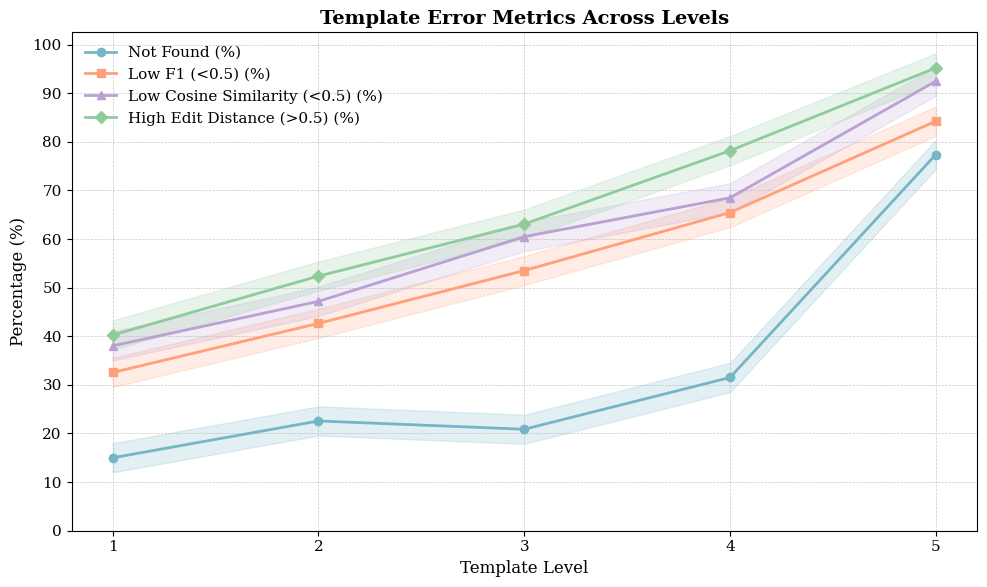

In [134]:
import numpy as np
levels = [1, 2, 3, 4, 5]
percent_not_found = [15.00, 22.58, 20.87, 31.52, 77.39]
percent_low_f1 = [32.55, 42.65, 53.52, 65.45, 84.25]
percent_low_cos_sim = [38.03, 47.18, 60.49, 68.48, 92.47]
percent_edit_dist =  [40.26, 52.38, 63.08, 78.18, 95.21]

# Convert to arrays for math
levels_np = np.array(levels)
padding = 3

fig, ax = plt.subplots(figsize=(10, 6))

# Plot and narrow band fill for each metric
def plot_band(line, color, label, marker):
    ax.plot(levels_np, line, marker=marker, linewidth=2, label=label, color=color)
    ax.fill_between(levels_np, np.array(line) - padding, np.array(line) + padding, 
                    color=color, alpha=0.2)

plot_band(percent_not_found, '#76B5C5', 'Not Found (%)', 'o')
plot_band(percent_low_f1, '#FFA07A', 'Low F1 (<0.5) (%)', 's')
plot_band(percent_low_cos_sim, '#BAA0D3', 'Low Cosine Similarity (<0.5) (%)', '^')
plot_band(percent_edit_dist, '#8FCB9B', 'High Edit Distance (>0.5) (%)', 'D')

# Labels and title
ax.set_xlabel('Template Level', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Template Error Metrics Across Levels', fontsize=14, fontweight='bold')

# Ticks and grid
ax.set_xticks(levels)
ax.set_yticks(range(0, 101, 10))
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Legend
ax.legend(frameon=False, fontsize=11)

# Layout
plt.tight_layout()
plt.savefig("template_error_metrics_total.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()


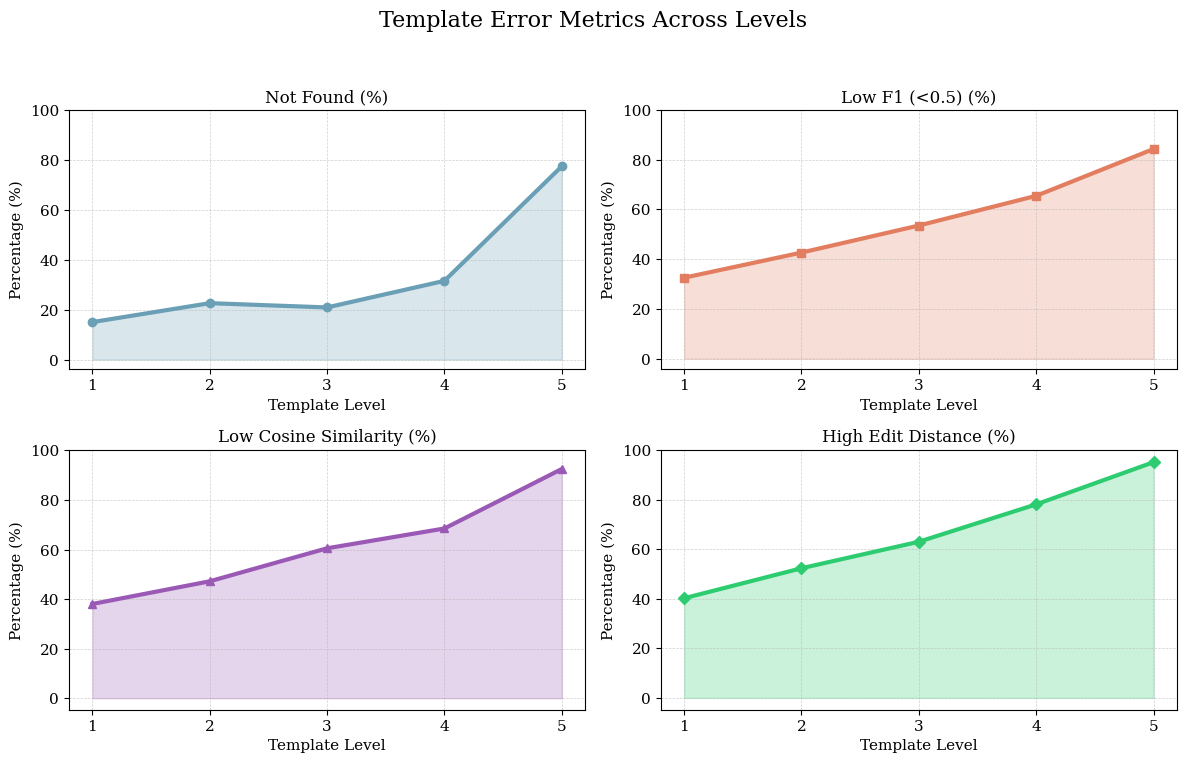

In [135]:
import matplotlib.pyplot as plt
import numpy as np

# Data
levels = [1, 2, 3, 4, 5]
percent_not_found = [15.00, 22.58, 20.87, 31.52, 77.39]
percent_low_f1 = [32.55, 42.65, 53.52, 65.45, 84.25]
percent_low_cos_sim = [38.03, 47.18, 60.49, 68.48, 92.47]
percent_edit_dist = [40.26, 52.38, 63.08, 78.18, 95.21]

metrics = [
    (percent_not_found, '#6A9FB5', 'Not Found (%)', 'o'),
    (percent_low_f1, '#E27D60', 'Low F1 (<0.5) (%)', 's'),
    (percent_low_cos_sim, '#9B59B6', 'Low Cosine Similarity (%)', '^'),
    (percent_edit_dist, '#2ECC71', 'High Edit Distance (%)', 'D')
]

levels_np = np.array(levels)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for ax, (data, color, label, marker) in zip(axs, metrics):
    ax.plot(levels_np, data, marker=marker, linewidth=3, label=label, color=color)
    ax.fill_between(levels_np, data, color=color, alpha=0.25)
    
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Template Level', fontsize=11)
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_xticks(levels)
    ax.set_yticks(range(0, 101, 20))
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    ax.set_facecolor('#FFFFFF')  # classic white background

# Overall title and layout
plt.suptitle('Template Error Metrics Across Levels', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("template_error_metrics.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


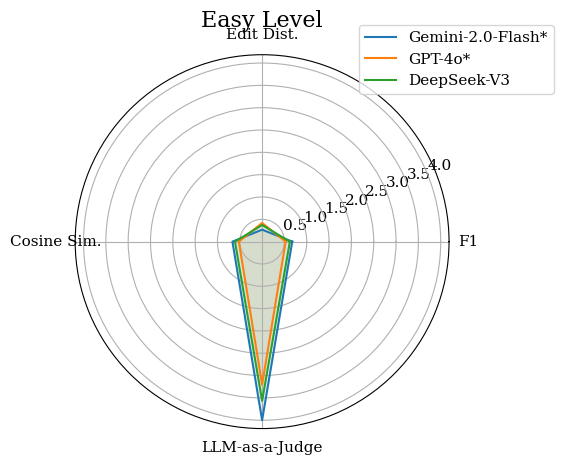

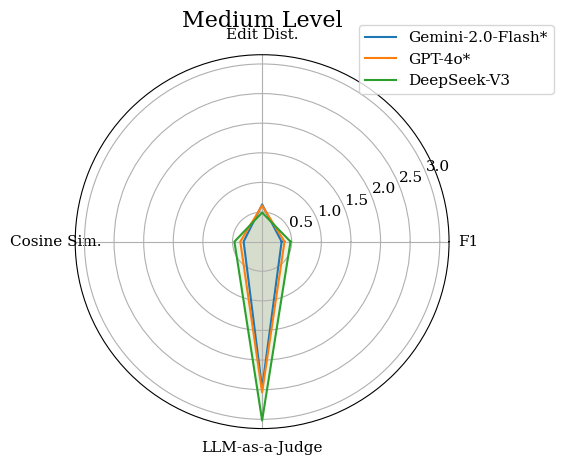

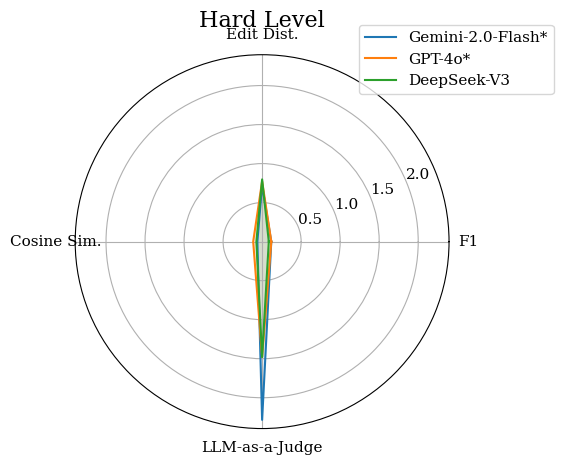

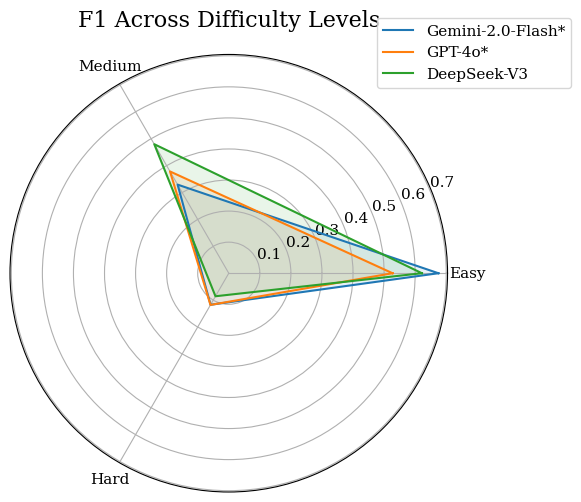

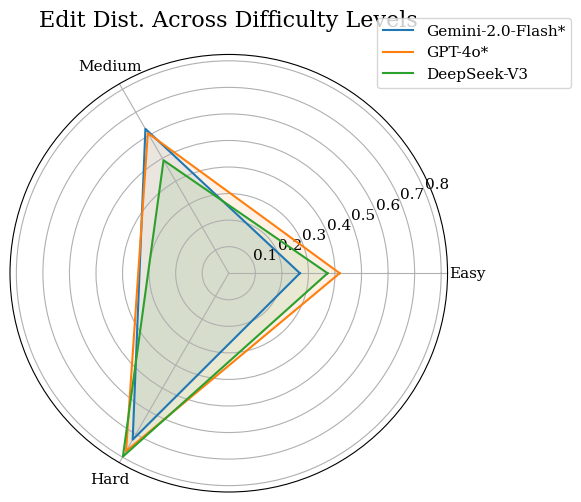

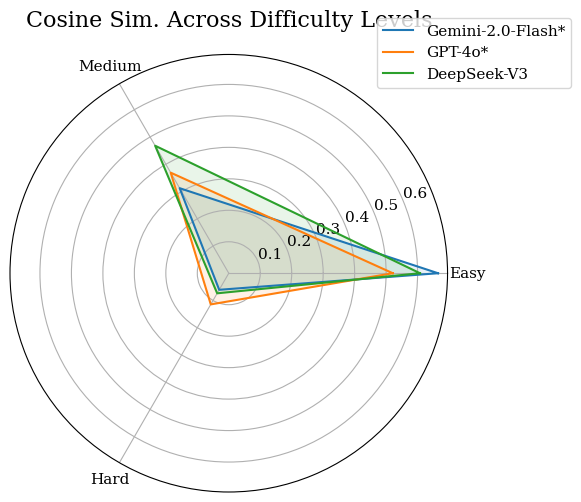

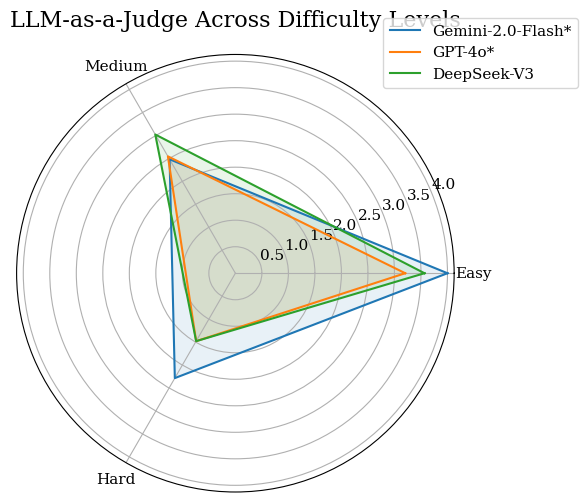

In [136]:
models = ["Gemini-2.0-Flash*", "GPT-4o*", "DeepSeek-V3"]
difficulty_levels = ["Easy", "Medium", "Hard"]
metrics = ["F1", "Edit Dist.", "Cosine Sim.", "LLM-as-a-Judge"]

# [model][difficulty][metric]
data = {
    "Gemini-2.0-Flash*": {
        "Easy": [0.6748, 0.2679, 0.6650, 4.0000],
        "Medium": [0.3294, 0.6280, 0.3121, 2.4820],
        "Hard": [0.1172, 0.7238, 0.0608, 2.2838]
    },
    "GPT-4o*": {
        "Easy": [0.5272, 0.4177, 0.5213, 3.2034],
        "Medium": [0.3783, 0.6098, 0.3690, 2.5451],
        "Hard": [0.1178, 0.7738, 0.1144, 1.4795]
    },
    "DeepSeek-V3": {
        "Easy": [0.6218, 0.3722, 0.6077, 3.5668],
        "Medium": [0.4796, 0.4912, 0.4678, 3.0210],
        "Hard": [0.0856, 0.7975, 0.0737, 1.4795]
    }
}
def plot_radar_chart_difficulty(data, difficulty, metrics, models):
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    for model in models:
        values = data[model][difficulty]
        values += values[:1]
        ax.plot(angles, values, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_title(f'{difficulty} Level', size=16, pad=20)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

# Generate one for each difficulty level
for level in difficulty_levels:
    plot_radar_chart_difficulty(data, level, metrics, models)
def plot_radar_chart_metric(data, metric_index, metric_name, difficulty_levels, models):
    angles = np.linspace(0, 2 * np.pi, len(difficulty_levels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    for model in models:
        values = [data[model][level][metric_index] for level in difficulty_levels]
        values += values[:1]
        ax.plot(angles, values, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_title(f'{metric_name} Across Difficulty Levels', size=16, pad=20)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(difficulty_levels)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

# Generate one for each metric
for i, metric in enumerate(metrics):
    plot_radar_chart_metric(data, i, metric, difficulty_levels, models)
